# Assignment 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers,models,optimizers
from sklearn.preprocessing import MinMaxScaler

In [2]:
roll_no = 102317112
batch_size = 128
latent_dim = 8
epochs = 3500

In [3]:
def data(r):
  df = pd.read_csv('data.csv',encoding='ISO-8859-1')
  x = df['no2'].dropna().values.reshape(-1,1)

  ar = 0.5 * (r % 7)
  br = 0.3 * ((r % 5) + 1)

  z = x + ar * np.sin(br * x)

  scaler = MinMaxScaler(feature_range=(-1, 1))
  z_scaled = scaler.fit_transform(z)
  return z_scaled, scaler

In [4]:
z_data,scaler = data(roll_no)

/tmp/ipython-input-1517822748.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv',encoding='ISO-8859-1')


In [5]:
def build_generator():
  model = models.Sequential([
      layers.Dense(64, input_dim=latent_dim),
      layers.LeakyReLU(0.2),
      layers.BatchNormalization(),
      layers.Dense(128),
      layers.LeakyReLU(0.2),
      layers.Dense(1, activation='tanh')
  ])
  return model

In [6]:
def build_discriminator():
  model = models.Sequential([
      layers.Dense(128, input_dim=1),
      layers.LeakyReLU(0.2),
      layers.Dropout(0.3),
      layers.Dense(64),
      layers.LeakyReLU(0.2),
      layers.Dense(1, activation='sigmoid')
  ])
  return model

In [7]:
generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer = optimizers.Adam(0.0002,0.5),loss = 'binary_crossentropy')

discriminator.trainable = False
gan = models.Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(0.0001, 0.5))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
for e in range(epochs):
  idx = np.random.randint(0,z_data.shape[0],batch_size)
  real_z = z_data[idx]

  noise = np.random.normal(0,1,(batch_size,latent_dim))
  fake_z = generator.predict(noise,verbose = 0)

  d_loss_real = discriminator.train_on_batch(real_z,np.ones((batch_size,1)) * 0.9)
  d_loss_fake = discriminator.train_on_batch(fake_z,np.zeros((batch_size,1)))

  noise = np.random.normal(0,1,(batch_size,latent_dim))
  g_loss = gan.train_on_batch(noise,np.ones((batch_size,1)))

  if e % 500 == 0:
    print(f"Epoch {e} | D Loss : {d_loss_real + d_loss_fake:.4f} | G Loss : {g_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss : 1.4445 | G Loss : 0.7117
Epoch 500 | D Loss : 1.4233 | G Loss : 0.7006
Epoch 1000 | D Loss : 1.4239 | G Loss : 0.6988
Epoch 1500 | D Loss : 1.4242 | G Loss : 0.6980
Epoch 2000 | D Loss : 1.4246 | G Loss : 0.6974
Epoch 2500 | D Loss : 1.4248 | G Loss : 0.6970
Epoch 3000 | D Loss : 1.4250 | G Loss : 0.6968


In [9]:
noise = np.random.normal(0,1,(10000,latent_dim))
gen_samples = scaler.inverse_transform(generator.predict(noise))
real_samples = scaler.inverse_transform(z_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


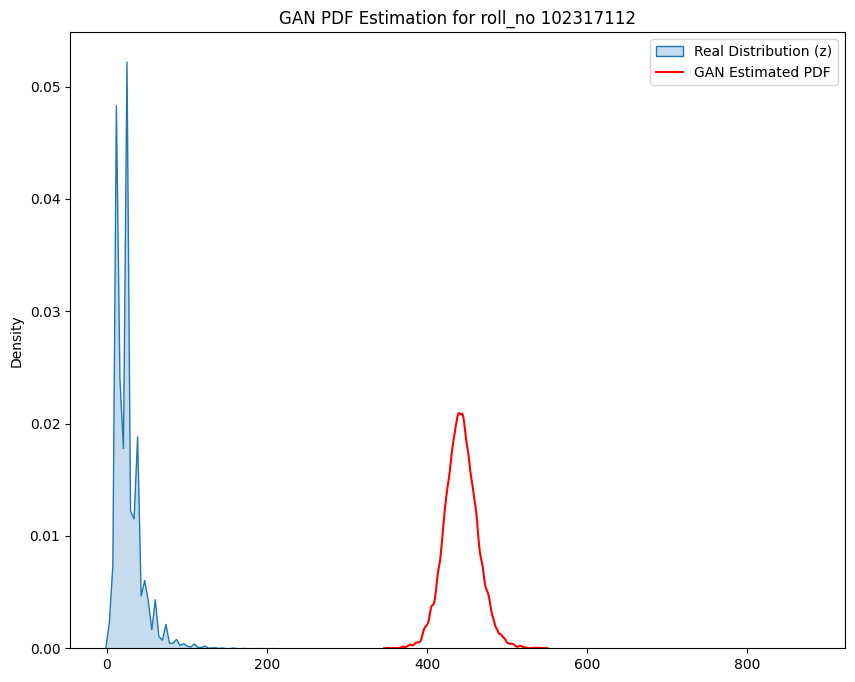

In [10]:
plt.figure(figsize = (10,8))
sns.kdeplot(real_samples.flatten(),label = 'Real Distribution (z)',fill = True,bw_adjust = 0.5)
sns.kdeplot(gen_samples.flatten(),label = 'GAN Estimated PDF',color = 'red',bw_adjust = 0.5)
plt.legend()
plt.title(f'GAN PDF Estimation for roll_no {roll_no}')
plt.show()